# Analisis Morfologico

## Importaciones

In [1]:
import sys
import os
import ast
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from pathlib import Path
sys.path.append(os.path.abspath('..'))
from src.data.mongo_storage import _get_default_collection
from src.analysis.metrics import calcular_metricas_spacy, resumen_global

print('✓ Librerías importadas correctamente')


✓ Librerías importadas correctamente


## Carga de datos

In [2]:
# Cargar canciones con pos_tags.spacy desde MongoDB
col = _get_default_collection()
docs = list(col.find(
    {'pos_tags.spacy': {'$ne': None}},
    {'_id': 1, 'Song': 1, 'Artist': 1, 'Genre': 1,
     'Song year': 1, 'pos_tags': 1}
))

df_spacy = pd.DataFrame(docs)
# Renombrar pos_tags.spacy a la columna que espera calcular_metricas_spacy
df_spacy['pos_tags_spacy'] = df_spacy['pos_tags'].apply(
    lambda x: x['spacy'] if x and x.get('spacy') else []
)
print(f'✓ {len(df_spacy)} canciones cargadas desde MongoDB')
df_spacy.head()


✓ 9246 canciones cargadas desde MongoDB


,_id,Song,Artist,Genre,Song year,pos_tags,pos_tags_spacy
0,69d7e6fb0126095ee5e13af6,craftsmanship,buck-65,Hip-Hop,2005,"{'nltk': [{'token': 'Most', 'tag': 'JJS'}, {'t...","[{'token': 'Most', 'pos': 'ADJ', 'tag': 'JJS',..."
1,69d7e6fb0126095ee5e13af7,come-on-out,the-elwins,Indie,2012,"{'nltk': [{'token': 'Take', 'tag': 'VB'}, {'to...","[{'token': 'Take', 'pos': 'VERB', 'tag': 'VB',..."
2,69d7e6fb0126095ee5e13af8,riot,bullet-for-my-valentine,Metal,2013,"{'nltk': [{'token': 'Are', 'tag': 'NNP'}, {'to...","[{'token': 'Are', 'pos': 'AUX', 'tag': 'VBP', ..."
3,69d7e6fb0126095ee5e13af9,that-s-what-girls-do,dream-street,Pop,2007,"{'nltk': [{'token': 'You', 'tag': 'PRP'}, {'to...","[{'token': 'You', 'pos': 'PRON', 'tag': 'PRP',..."
4,69d7e6fb0126095ee5e13afa,believe-in-a-dollar,cassidy,Hip-Hop,2012,"{'nltk': [{'token': 'Do', 'tag': 'VBP'}, {'tok...","[{'token': 'Do', 'pos': 'AUX', 'tag': 'VBP', '..."


## Cálculo de métricas

In [3]:
df_metricas = calcular_metricas_spacy(df_spacy)
print("Métricas calculadas correctamente")
df_metricas.head()


✓ métricas guardadas en MongoDB: 9246/9246 canciones
Métricas calculadas correctamente


,_id,Song,Artist,Genre,Song year,total_tokens,vocab_unico,n_sustantivos,n_verbos,n_adjetivos,...,n_auxiliares,n_interjecciones,n_numerales,densidad_lexica,ttr,ratio_sust_verb,ratio_adj_sust,ratio_adv_verb,ratio_pron_sust,ratio_func_cont
0,69d7e6fb0126095ee5e13af6,craftsmanship,buck-65,Hip-Hop,2005,427,199,83,101,32,...,31,1,1,0.4801,0.4660,0.8218,0.3855,0.1980,0.8072,0.8293
1,69d7e6fb0126095ee5e13af7,come-on-out,the-elwins,Indie,2012,293,108,45,86,16,...,20,0,0,0.4710,0.3686,0.5233,0.3556,0.1279,1.4222,0.8913
2,69d7e6fb0126095ee5e13af8,riot,bullet-for-my-valentine,Metal,2013,204,63,45,48,5,...,8,29,1,0.4902,0.3088,0.9375,0.1111,0.2083,0.4889,0.6100
3,69d7e6fb0126095ee5e13af9,that-s-what-girls-do,dream-street,Pop,2007,229,77,27,57,14,...,10,18,2,0.4105,0.3362,0.4737,0.5185,0.1053,2.3333,1.0213
4,69d7e6fb0126095ee5e13afa,believe-in-a-dollar,cassidy,Hip-Hop,2012,249,102,55,55,10,...,18,4,0,0.4618,0.4096,1.0000,0.1818,0.2364,0.7273,0.9217


## Métricas globales

In [4]:
df_tot=resumen_global(df_metricas)


=== MÉTRICAS GLOBALES (estadísticas por canción) ===

=== TOTALES DEL CORPUS ===
                  total_corpus  promedio_por_cancion
total_tokens           2565887                277.51
vocab_unico             971254                105.05
n_sustantivos           537723                 58.16
n_verbos                594251                 64.27
n_adjetivos             124503                 13.47
n_adverbios             138378                 14.97
n_pronombres            485901                 52.55
n_propios               131423                 14.21
n_auxiliares            155889                 16.86
n_interjecciones         46400                  5.02
n_numerales              11882                  1.29


## Distribución Global de Categorías Gramaticales en el Corpus

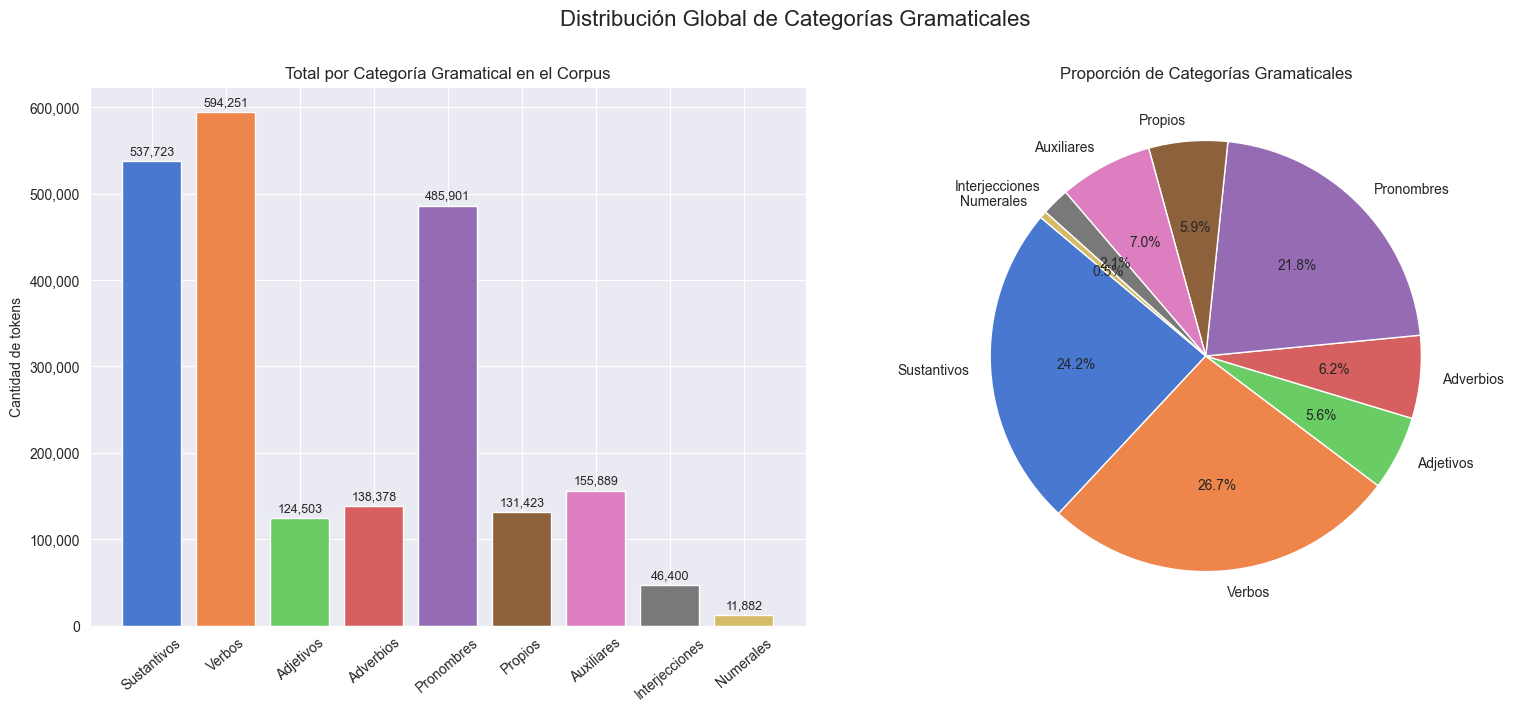

In [5]:
cats = ['n_sustantivos','n_verbos','n_adjetivos','n_adverbios',
        'n_pronombres','n_propios','n_auxiliares','n_interjecciones','n_numerales']
labels = ['Sustantivos','Verbos','Adjetivos','Adverbios',
          'Pronombres','Propios','Auxiliares','Interjecciones','Numerales']

valores = df_tot.loc[cats, 'total_corpus']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Barras
bars = axes[0].bar(labels, valores.values, color=sns.color_palette('muted', len(cats)))
axes[0].set_title('Total por Categoría Gramatical en el Corpus')
axes[0].set_ylabel('Cantidad de tokens')
axes[0].tick_params(axis='x', rotation=40)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

# Pie
axes[1].pie(valores.values, labels=labels, autopct='%1.1f%%',
            colors=sns.color_palette('muted', len(cats)), startangle=140)
axes[1].set_title('Proporción de Categorías Gramaticales')

plt.suptitle('Distribución Global de Categorías Gramaticales', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## Densidad Léxica por Género Musical

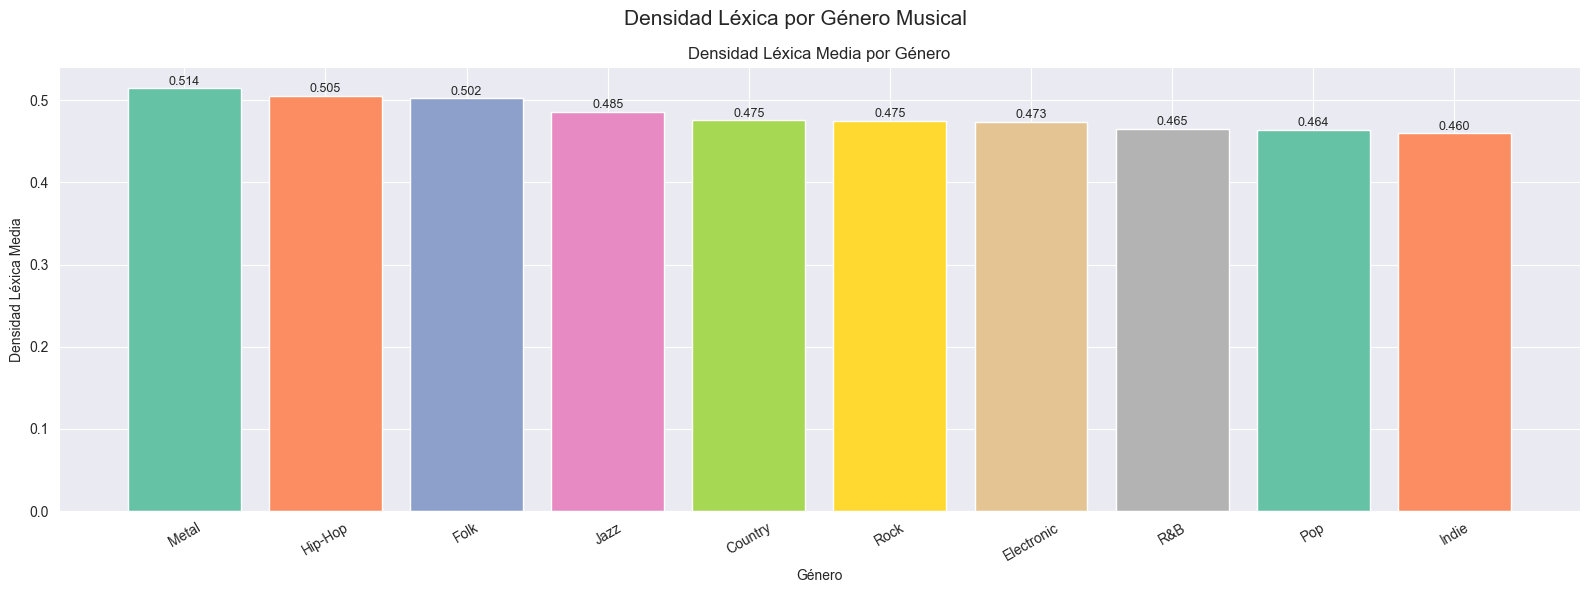

Género con mayor densidad léxica media: Metal (0.514)
Género con menor densidad léxica media: Indie (0.460)


In [6]:
fig, ax = plt.subplots(figsize=(16, 6))

# Medias
medias = df_metricas.groupby('Genre')['densidad_lexica'].mean().sort_values(ascending=False)

bars = ax.bar(
    medias.index,
    medias.values,
    color=sns.color_palette('Set2', len(medias))
)

ax.set_title('Densidad Léxica Media por Género')
ax.set_xlabel('Género')
ax.set_ylabel('Densidad Léxica Media')
ax.tick_params(axis='x', rotation=30)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.001,
        f'{bar.get_height():.3f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.suptitle('Densidad Léxica por Género Musical', fontsize=15)
plt.tight_layout()
plt.show()

print(f'Género con mayor densidad léxica media: {medias.idxmax()} ({medias.max():.3f})')
print(f'Género con menor densidad léxica media: {medias.idxmin()} ({medias.min():.3f})')


## Distribución de Total de Tokens por Género (Longitud de Canciones)

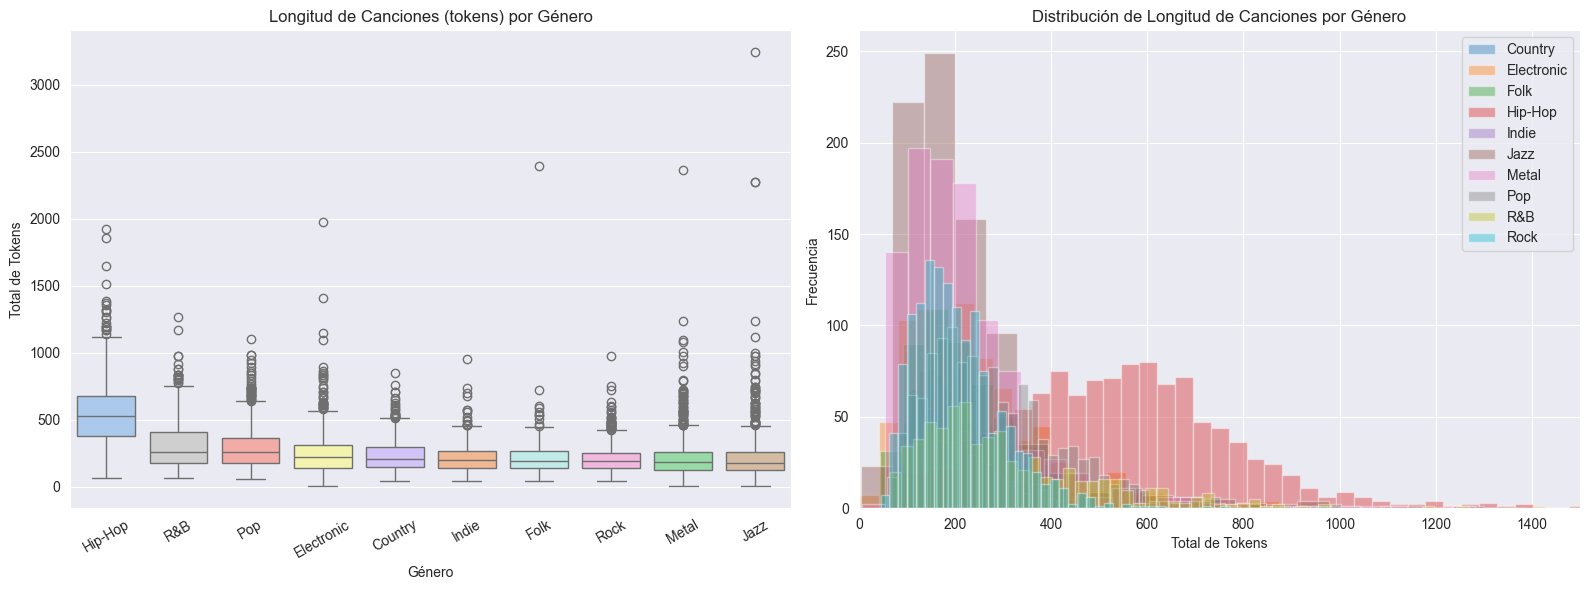

Estadísticas de longitud por género:
             mean  median    std
Genre                           
Hip-Hop     537.9   531.0  237.6
R&B         310.8   262.0  184.8
Pop         286.1   258.0  148.6
Electronic  251.6   222.0  168.6
Country     231.3   205.5  109.1
Jazz        223.1   176.0  206.7
Metal       219.4   188.0  153.3
Indie       216.3   197.0  108.4
Folk        214.8   194.0  138.7
Rock        206.1   190.0   94.6


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(
    data=df_metricas,
    x='Genre',
    y='total_tokens',
    order=df_metricas.groupby('Genre')['total_tokens']
          .median()
          .sort_values(ascending=False)
          .index,
    hue='Genre',
    palette='pastel',
    legend=False,
    ax=axes[0]
)

axes[0].set_title('Longitud de Canciones (tokens) por Género')
axes[0].set_xlabel('Género')
axes[0].set_ylabel('Total de Tokens')
axes[0].tick_params(axis='x', rotation=30)

# Histograma general
for genre, grp in df_metricas.groupby('Genre'):
    axes[1].hist(grp['total_tokens'], bins=50, alpha=0.4, label=genre)

axes[1].set_title('Distribución de Longitud de Canciones por Género')
axes[1].set_xlabel('Total de Tokens')
axes[1].set_ylabel('Frecuencia')
axes[1].set_xlim(0, 1500)
axes[1].legend()

plt.tight_layout()
plt.show()

stats_len = df_metricas.groupby('Genre')['total_tokens'] \
    .agg(['mean', 'median', 'std']) \
    .round(1) \
    .sort_values('mean', ascending=False)

print('Estadísticas de longitud por género:')
print(stats_len.to_string())